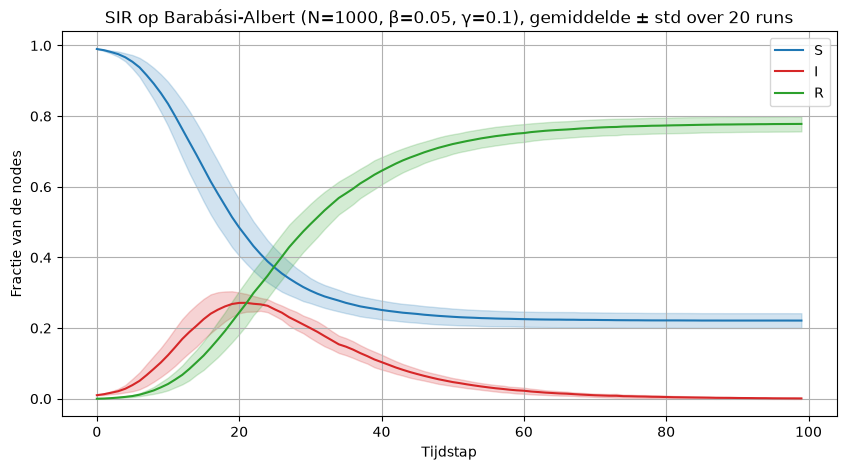

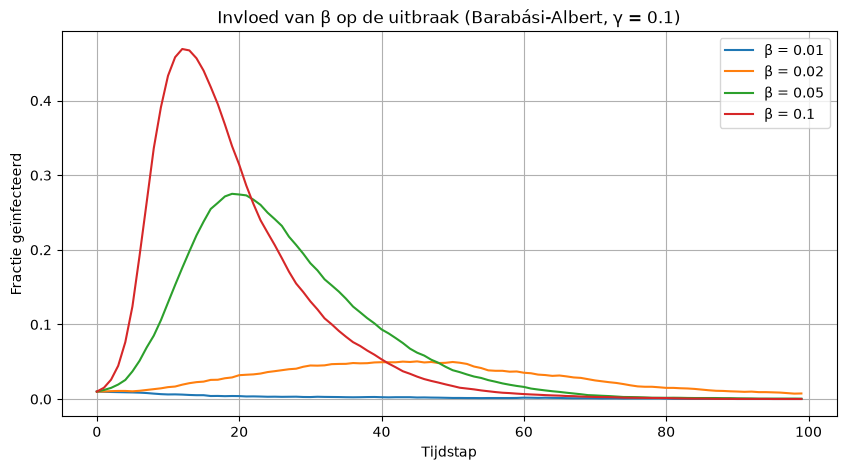

Contactnetwerk: 374 nodes, 1265 edges


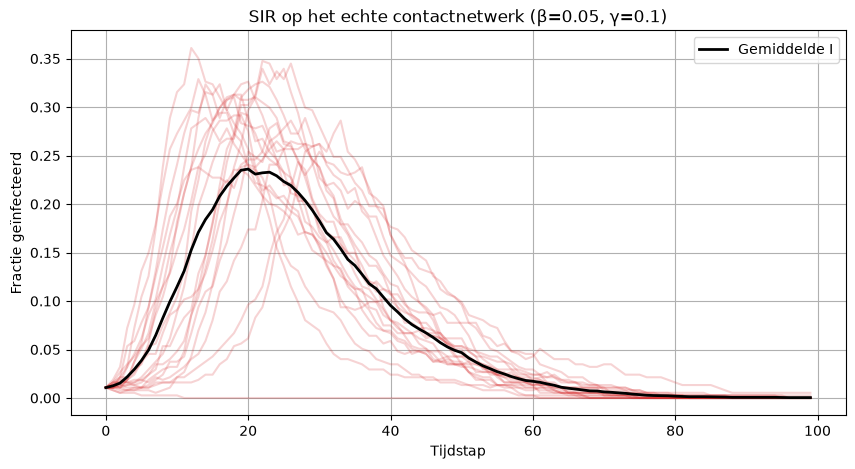

In [4]:
# Problem 2: SIR op netwerken met NDlib

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import ndlib.models.ModelConfig as mc
import ndlib.models.epidemics as ep


def laad_contactnetwerk(pad="transmission_network.csv"):
    # Het bestand is een adjacency-matrix: rij- en kolomnamen zijn node-ID's,
    # de waarden zijn het aantal contacten tussen twee personen (0 = geen edge).
    df = pd.read_csv(pad, sep=";", index_col=0)
    # De kolomnamen worden als tekst ingelezen, de index als getal: gelijk maken
    df.columns = df.columns.astype(int)
    g = nx.from_pandas_adjacency(df)   # gewicht komt in edge-attribuut 'weight'
    return g


def simuleer_sir(g, beta, gamma, frac_geinfecteerd=0.01, n_stappen=100, seed=None):
    # Eén SIR-simulatie op graaf g met NDlib.
    #  beta  = kans per stap dat een geïnfecteerde een vatbare buur besmet
    #  gamma = kans per stap dat een geïnfecteerde herstelt
    # Geeft arrays S, I, R terug (aantal nodes per tijdstap).
    rng = np.random.default_rng(seed)

    model = ep.SIRModel(g)
    config = mc.Configuration()
    config.add_model_parameter("beta", beta)
    config.add_model_parameter("gamma", gamma)

    # Zelf de startinfecties kiezen (minstens 1), zodat het reproduceerbaar is
    n_start = max(1, int(round(frac_geinfecteerd * g.number_of_nodes())))
    start_nodes = list(rng.choice(list(g.nodes()), size=n_start, replace=False))
    config.add_model_initial_configuration("Infected", start_nodes)

    model.set_initial_status(config)

    # Simuleren en omzetten naar tijdreeksen per status (0 = S, 1 = I, 2 = R)
    iteraties = model.iteration_bunch(n_stappen, node_status=False)
    trends = model.build_trends(iteraties)
    tellingen = trends[0]["trends"]["node_count"]
    S = np.array(tellingen[0])
    I = np.array(tellingen[1])
    R = np.array(tellingen[2])
    return S, I, R


def simuleer_sir_meerdere(g, beta, gamma, n_runs=20, frac_geinfecteerd=0.01, n_stappen=100):
    # Meerdere runs met dezelfde parameters, zodat we gemiddelde en spreiding zien.
    # Geeft arrays van vorm (n_runs, n_stappen) terug.
    S_runs, I_runs, R_runs = [], [], []
    for run in range(n_runs):
        S, I, R = simuleer_sir(g, beta, gamma, frac_geinfecteerd, n_stappen, seed=run)
        S_runs.append(S)
        I_runs.append(I)
        R_runs.append(R)
    return np.array(S_runs), np.array(I_runs), np.array(R_runs)


# Test 1: één modelnetwerk (Barabási-Albert)
g_ba = nx.barabasi_albert_graph(n=1000, m=3, seed=1)
beta, gamma = 0.05, 0.1

S_runs, I_runs, R_runs = simuleer_sir_meerdere(g_ba, beta, gamma, n_runs=20)
N_ba = g_ba.number_of_nodes()
t = np.arange(I_runs.shape[1])

plt.figure(figsize=(10, 5))
for kleur, runs, naam in [('tab:blue', S_runs, 'S'), ('tab:red', I_runs, 'I'), ('tab:green', R_runs, 'R')]:
    gem = runs.mean(axis=0) / N_ba
    std = runs.std(axis=0) / N_ba
    plt.plot(t, gem, color=kleur, label=naam)
    plt.fill_between(t, gem - std, gem + std, color=kleur, alpha=0.2)
plt.xlabel('Tijdstap')
plt.ylabel('Fractie van de nodes')
plt.title(f'SIR op Barabási-Albert (N={N_ba}, β={beta}, γ={gamma}), gemiddelde ± std over 20 runs')
plt.legend()
plt.grid(True)
plt.show()


# Test 2: beta variëren (opzet voor de experimenten later)
beta_waarden = [0.01, 0.02, 0.05, 0.1]

plt.figure(figsize=(10, 5))
for beta_i in beta_waarden:
    S_runs, I_runs, R_runs = simuleer_sir_meerdere(g_ba, beta_i, gamma, n_runs=10)
    plt.plot(t, I_runs.mean(axis=0) / N_ba, label=f'β = {beta_i}')
plt.xlabel('Tijdstap')
plt.ylabel('Fractie geïnfecteerd')
plt.title(f'Invloed van β op de uitbraak (Barabási-Albert, γ = {gamma})')
plt.legend()
plt.grid(True)
plt.show()


# Test 3: het echte contactnetwerk inladen en dezelfde functie gebruiken
g_echt = laad_contactnetwerk("transmission_network.csv")
print(f"Contactnetwerk: {g_echt.number_of_nodes()} nodes, {g_echt.number_of_edges()} edges")

S_runs, I_runs, R_runs = simuleer_sir_meerdere(g_echt, beta, gamma, n_runs=20)
N_echt = g_echt.number_of_nodes()
t_echt = np.arange(I_runs.shape[1])

plt.figure(figsize=(10, 5))
plt.plot(t_echt, I_runs.T / N_echt, color='tab:red', alpha=0.2)
plt.plot(t_echt, I_runs.mean(axis=0) / N_echt, color='k', lw=2, label='Gemiddelde I')
plt.xlabel('Tijdstap')
plt.ylabel('Fractie geïnfecteerd')
plt.title(f'SIR op het echte contactnetwerk (β={beta}, γ={gamma})')
plt.legend()
plt.grid(True)
plt.show()
